This Mars Rover model complies with the assumption of markovianity by the fact that the actions taken by the rover at any given time step depends only on the current state of the rover.

## 1.2 
Expressing the problem as a Markov Process

Definition of a Markov Process:
A tuple <S, P> where S is a set of states and P is a transition probability matrix that defines the probabilities of transitioning from one state to another.

For our Mars Rover problem, the set of states S = {Explore, Pictures, Sample, Recharge, Malfunction}

The transition probability matrix P=
\[
P =
\begin{array}{c|ccccc}
 & Explore & Pictures & Sample & Recharge & Malfunction \\
\hline
Explore & 0.7 & 0.6 & 0.35 & 1.0 & 0.0 \\
Pictures & 0.1 & 0.0 & 0.0 & 0.0 & 0.0 \\
Sample & 0.1 & 0.4 & 0.3 & 0.0 & 0.0 \\
Recharge & 0.1 & 0.0 & 0.3 & 0.0 & 0.0 \\
Malfunction & 0.0 & 0.0 & 0.05 & 0.0 & 1.0
\end{array}
\]


## 1.3
When you are in the normal explore state, the rover has no possibility of malfunctioning.
When the rover malfunctions, it cannot transition back to any other state. e.g. the reachability to other states is compromised.

## 1.4
Probability of malfunctioning within the first 10 minutes is 0, as the rover cannot transition to the malfunction state from the explore state.

In the next 10 minutes, the only way it can reach the malfunction state is through the sample state. The probability of transitioning from explore to sample is 0.35, and from sample to malfunction is 0.05. Therefore, the probability of malfunctioning within the next 10 minutes is 0.35 * 0.05 = 0.0175 or 1.75%.

In the 10 minutes after that, we have more possible paths to malfunction. The rover can transition from explore to pictures, then to sample, and finally to malfunction. The probability of this path is 0.6 * 0.4 * 0.05 = 0.012 or 1.2%.
We also have the path from explore to sample to malfunction, which we already calculated as 0.0175 or 1.75%.
And the path from explore to sample to sample to malfunction, which is 0.35 * 0.3 * 0.05 = 0.00525 or 0.525%.
Adding these probabilities together, the total probability of malfunctioning within the next 30 minutes is 0.0175 + 0.012 + 0.00525 = 0.03475 or 3.475%.

## 1.5
If the probability of malfunctioning depends on the times the rover has been in the sample state, then the Markov property is violated. This is because the transition probabilities does not only depend on the current state but also on the past history of states.

## 1.6
The tic-tac-toe game can be modeled as a Markov Process as your next action only depends on the current state of the board.

## 1.7
You have 3 options for every square on the tic-tac-toe board: X, O and empty. Since there are 9 squares, the total number of states is 3^9 = 19683.


## Exercise 2

Expected reward for the first 10 minutes:
E[R | Explore] = 0.7 * 0 + 0.1 * 5 + 0.1 * 20 + 0.1 * 0 + 0 * (-100) = 2.5

Probability of negative reward within first 20 minutes:
P[Negative Reward | Explore] = P[Malfunction | Explore] = 0.0175 or 1.75%
This is because the only way to get a negative reward is to transition to the malfunction state, which we calculated in Exercise 1.4.

## 3. Markov Decision Processes

To model it as a Markov Decision Process, we need to define the set of actions A and the reward function R.
We have the same set of states S = {Explore, Pictures, Sample, Recharge, Malfunction}
The set of actions A = {Run program}
Probability transition matrix P is the same as defined in Exercise 1.2. because we ess


## Part 2

1. To model this as a MDP we need the to define the tuple <S, A, P, R, gamma> where S is the set of states, A is the set of actions, P is the transition probability matrix and R is the reward function. 
- S = {position}
- A = {straight, diagonal up, diagonal down}
- P is the transition probability matrix. But all transitions are deterministic, so the probability of transitioning to the next state is 1 for the action taken and 0 for all other actions.
- R is roughness of the terrain at the terrain the rover is currently on. More reward for terrain that the robot can move through faster.
- gamma is the discount factor.

In [10]:
# Policy evalutation algorithm
import numpy as np
import matplotlib.pyplot as plt
from mountain import Mountain_one

env = Mountain_one()
terrain = env.get_map()
n_rows, n_cols = terrain.shape  # should be (31, 100)
actions = env.actions           # ['upforward', 'forward', 'downforward']

print("shape:", terrain.shape)




shape: (31, 100)


In [11]:
import numpy as np
from mountain import Mountain_one

def policy_evaluation(env, policy, gamma=1.0, theta=1e-8, max_iters=10000):
    n_rows, n_cols = env.get_map().shape
    V = np.zeros((n_rows, n_cols), dtype=float)  # initialize v^(0)

    for k in range(max_iters):                    # for k = 1...T
        delta = 0.0
        V_old = V.copy()

        for i in range(n_rows):                   # for each state s
            for j in range(n_cols):
                s = (i, j)

                if j == n_cols - 1:               # terminal-like last column
                    V[i, j] = 0.0
                    continue

                a = policy[i, j]                  # deterministic policy pi(s)
                s_next = env.next_state(s, a)
                r = env.get_reward(s, a)

                V[i, j] = r + gamma * V_old[s_next]   # update from previous sweep
                delta = max(delta, abs(V[i, j] - V_old[i, j]))

        if delta < theta:                         # convergence criterion
            return V, k + 1

    return V, max_iters


In [12]:
# 1
policy = np.full((n_rows, n_cols), "forward", dtype=object)

V_forward, iters = policy_evaluation(env, policy, gamma=1.0, theta=1e-8)
print("Converged in", iters, "iterations")
print("V shape:", V_forward.shape)
print("V_forward:", V_forward[0,0])


Converged in 99 iterations
V shape: (31, 100)
V_forward: -67.43137399


In [13]:
# 1) Build a flipped environment (horizontal flip)
env_flip = Mountain_one()
env_flip.map = env_flip.get_map()[:, ::-1].copy()

# 2) "Always forward" on flipped map
n_rows, n_cols = env_flip.get_map().shape
policy_forward_flip = np.full((n_rows, n_cols), "forward", dtype=object)

v_flip, n_iter = policy_evaluation(env_flip, policy_forward_flip, gamma=1.0, theta=1e-8)
print("Converged in", n_iter, "iterations")


Converged in 99 iterations


In [15]:
# Best start in first column for original run
start_vals_orig = V_forward[:, 0]
best_row_orig = int(np.argmax(start_vals_orig))
best_val_orig = float(start_vals_orig[best_row_orig])

# Best start in first column for flipped run
# (equivalent to best start in last column of original map)
start_vals_flip = v_flip[:, 0]
best_row_flip = int(np.argmax(start_vals_flip))
best_val_flip = float(start_vals_flip[best_row_flip])

print("Original map (start at j=0):")
print("  best row:", best_row_orig, "best value:", best_val_orig)

print("Flipped map (start at j=0, i.e. original j=99):")
print("  best row:", best_row_flip, "best value:", best_val_flip)


Original map (start at j=0):
  best row: 7 best value: -35.72156986299999
Flipped map (start at j=0, i.e. original j=99):
  best row: 7 best value: -35.721569863000006


## 6.4
Because the state-value function is calculated based on a reward function that is based on the roughness of the terrain, and there are therefore no positive rewards, just negative rewards for going to rough terrain. Therefore we get negative state-value function values.

When you flip the columns (from going left to right, to going right to left), the state-value functions are the same. This is because the state-value function is calculated based on the reward function, which is based on the roughness of the terrain. Since the roughness of the terrain is the same regardless of the direction you are going, the state-value function will also be the same.

But since you change the ordering from left to right, to right to left, the calculation of the state-value function is more efficient as you can calculate the state-value function for the first column, and then use that to calculate the state-value function for the next column, and so on. This is because the state-value function for a given state depends on the state-value function of the next state, which is easier to calculate when you are going from right to left.

But result will be the same.

In [16]:
# Random deterministic policy over states:
# each state gets one random action from {'upforward','forward','downforward'}
rng = np.random.default_rng(42)  # seed for reproducibility
actions = np.array(env.actions, dtype=object)  # ['upforward','forward','downforward']

policy_random = rng.choice(actions, size=(n_rows, n_cols)).astype(object)
V_random, n_iter_random = policy_evaluation(env, policy_random, gamma=1.0, theta=1e-8)
print("Converged in", n_iter_random, "iterations")

Converged in 99 iterations


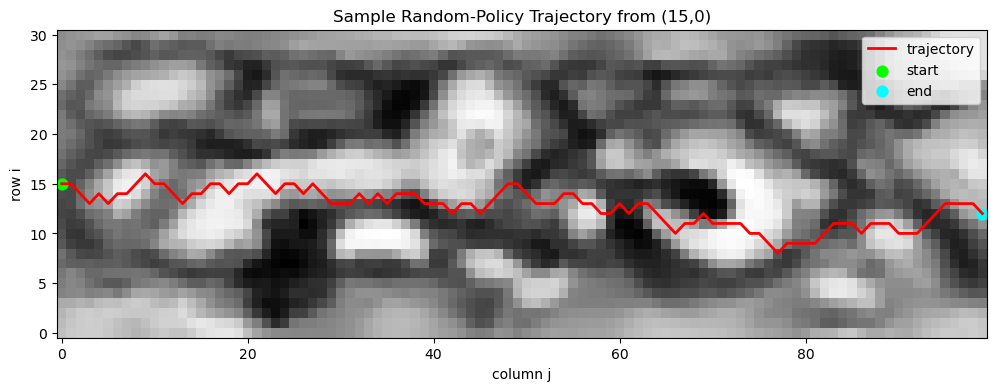

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def sample_trajectory(env, policy, start=(15, 0), max_steps=200):
    s = start
    traj = [s]

    for _ in range(max_steps):
        i, j = s
        if j == env.get_map().shape[1] - 1:  # reached last column
            break

        a = policy[i, j]                      # action from random policy table
        s = env.next_state(s, a)
        traj.append(s)

    return traj

# sample trajectory from (15,0) under your random policy
traj = sample_trajectory(env, policy_random, start=(15, 0))

# plot on top of terrain
terrain = env.get_map()
rows = [s[0] for s in traj]
cols = [s[1] for s in traj]

plt.figure(figsize=(12, 4))
plt.imshow(terrain, cmap="gray", aspect="auto")
plt.plot(cols, rows, color="red", linewidth=2, label="trajectory")
plt.scatter(cols[0], rows[0], color="lime", s=60, label="start")
plt.scatter(cols[-1], rows[-1], color="cyan", s=60, label="end")
plt.gca().invert_yaxis()  # optional: (0,0) at top-left visually
plt.title("Sample Random-Policy Trajectory from (15,0)")
plt.xlabel("column j")
plt.ylabel("row i")
plt.legend()
plt.show()


The number of iterations it takes to converge is the same for the forward policy and the random policy. This is because you always move one column to the right, and the state-value function for a given state depends on the state-value function of the next state. Therefore, the number of iterations it takes to converge is determined by the number of columns, which is the same for both policies. This is also made sure by the fact that it is not possible to exit the map or to go back to a previous column.

In [21]:
# assumes you already computed:
# v_forward from policy "forward"
# v_random from a random policy

print("v_forward(15,0) =", float(V_forward[15, 0]))
print("v_forward(3,0)  =", float(V_forward[3, 0]))
print("v_random(15,0)  =", float(V_random[15, 0]))

print("random(15,0) - forward(15,0) =", float(V_random[15, 0] - V_forward[15, 0]))


v_forward(15,0) = -57.80784459
v_forward(3,0)  = -52.796080069999995
v_random(15,0)  = -56.47059003000001
random(15,0) - forward(15,0) = 1.337254559999991


As we can see. The state-value function for the random policy when starting in (15,0) is better than the state-value function for the forward policy. However, the best state-value function is the combination of forward and initial start in (3,0).

It is very likely that the issue of exploration is affecting the final result. When the policy is random, it explores more of the state space and therefore has a better chance of finding a better state-value function. When the policy is forward, it only explores a limited part of the state space and therefore may not find the best state-value function. However